# PINN sign
PINN calculation based on data loss, physics loss, and sign loss. Input data for the data loss is point based.

In [1]:
import sys
sys.path.append('../src')

import absl.logging
absl.logging.set_verbosity(absl.logging.ERROR)

import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

In [3]:
## Refresh

import importlib
import pinn.train as train
import pinn.utils as utils
import pinn.model as model
import pinn.plot as plot

importlib.reload(train)
importlib.reload(utils)
importlib.reload(model)
importlib.reload(plot)

W0208 23:48:18.314652   33416 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0208 23:48:18.849940   33416 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.


<module 'pinn.plot' from '/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/notebooks/../src/pinn/plot.py'>

In [2]:
import jax
import jax.numpy as jnp

# Configure JAX to use only the CPU
# jax.config.update('jax_platform_name', 'cpu') 

print('jax:', jax.__version__)      # 0.7.2
print('devices:', jax.devices())    # [CudaDevice(id=0)]

import jax.experimental.layout as _layout
if not hasattr(_layout, 'DeviceLocalLayout'):
        # Provide a minimal alias so orbax can import function annotations\n",
        _layout.DeviceLocalLayout = _layout.Layout
        print('Patched jax.experimental.layout.DeviceLocalLayout ->', getattr(_layout, 'DeviceLocalLayout'))


import os
import numpy as np
import matplotlib.pyplot as plt
import pickle


jax: 0.7.2
devices: [CudaDevice(id=0), CudaDevice(id=1)]
Patched jax.experimental.layout.DeviceLocalLayout -> <class 'jax._src.layout.Layout'>


In [9]:
from flax.training import checkpoints
from pinn.train import create_train_state, train_step
from pinn.utils import load_pts_data, initial_loss, strip_meta, loss_dict_to_batched, save_ckpt, pick
from tqdm.notebook import trange

NUM_CHECKPOINTS_TO_KEEP = 1000   # Checkpoint retention count (older ones get removed)

## ===== PARAMETERS ========
lambda_1 = 100000       # Weight for boundary loss (data loss)
lambda_2 = 0            # Weight for physics loss
lambda_3 = 100000       # Weight for sign loss
shape = "bud_04"
additive = 0.2
missing  = 0.7
seed = 0

sdf_pretrain="uniform"
# sdf_pretrain="checkpoint"
num_steps = 10000
save_interval = 100
learning_rate = 1e-3

key = jax.random.PRNGKey(seed)
str_add = str(additive).replace('.', '')
str_miss = str(missing).replace('.', '')
if sdf_pretrain == "checkpoint":
    checkpoint_dir = os.path.abspath(f"../outputs/logs/{shape}/lambda_{lambda_1}_{lambda_2}_{lambda_3}_cont")
else:
    checkpoint_dir = os.path.abspath(f"../outputs/logs/{shape}/lambda_{lambda_1}_{lambda_2}_{lambda_3}")

## ===== LOAD INITIAL SHAPE FROM CHECKPOINT ========
if sdf_pretrain == "checkpoint":
    init_ckpt_path = os.path.abspath(f"../outputs/logs/{shape}/lambda_{lambda_1}_0_{lambda_3}/checkpoint_10000")
    init_ckpt = checkpoints.restore_checkpoint(ckpt_dir=init_ckpt_path, target=None)
    print("Ininitial shape: ", init_ckpt_path)

## ===== LOAD POINT DATA (EDGE, SIGN, and PHYS) ========
pts_path = f"../data/synthetic/pts_data"
edge = load_pts_data(f"{pts_path}/edge/e_{shape}_a{str_add}_m{str_miss}.npz", perm=(2,1,0))
sign = load_pts_data(f"{pts_path}/sign/s_{shape}.npz", perm=(2,1,0))
phys = load_pts_data(f"{pts_path}/phys/p_{shape}.npz", perm=(2,1,0))

# Put constant inputs on device once (avoid host->device every step)
phys_d = jax.device_put(strip_meta(phys))
edge_d = jax.device_put(strip_meta(edge))
sign_d = jax.device_put(strip_meta(sign))

## ===== CREATE TRAIN STATE ========
if sdf_pretrain == "checkpoint":
    state, model = create_train_state(key, lambda_1, lambda_2, lambda_3, learning_rate, init_ckpt=init_ckpt)
else:
    state, model = create_train_state(key, lambda_1, lambda_2, lambda_3, learning_rate, sdf_pretrain=sdf_pretrain)
print(f"Using lambda_1: {state.lambda_1}, lambda_2: {state.lambda_2}, lambda_3: {state.lambda_3}, learning_rate: {state.learning_rate}")

# Optionally: donate state to reduce peak memory
train_step_jit = jax.jit(train_step, donate_argnums=(0,))

# ===== INITIAL LOSS + CHECKPOINT (step=0) =====
init_d = initial_loss(state, edge_d, sign_d, phys_d)
init_record = {
    "step": 0,
    "total_loss":   pick(init_d, "total_loss", "total", "loss", default=0.0),
    "data_loss":    pick(init_d, "data_loss", "data", default=0.0),
    "phys_loss":    pick(init_d, "phys_loss", "phys", default=0.0),
    "sign_loss":    pick(init_d, "sign_loss", "sign", default=0.0),
}
save_ckpt(
    checkpoint_dir,
    step=0,
    state=state,
    loss_batch=loss_dict_to_batched([init_record]),
    keep=NUM_CHECKPOINTS_TO_KEEP,
)

# ===== TRAIN LOOP =====
buffer = []  # accumulate losses until save_interval

for step in trange(1, num_steps + 1):
    state, total, ld, lp, ls = train_step_jit(state, edge_d, sign_d, phys_d)

    buffer.append({
        "step": step,
        "total_loss": total,
        "data_loss": ld,
        "phys_loss": lp,
        "sign_loss": ls,
    })

    if step % save_interval == 0:
        save_ckpt(
            checkpoint_dir,
            step=step,
            state=state,
            loss_batch=loss_dict_to_batched(buffer),
            keep=NUM_CHECKPOINTS_TO_KEEP,
        )
        buffer.clear()


Pretraining the network using SDF...
Using lambda_1: 100000, lambda_2: 0, lambda_3: 100000, learning_rate: 0.001


  0%|          | 0/10000 [00:00<?, ?it/s]

### Analysis

/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/czii_gl_1/lambda_100000_0_100000_cont


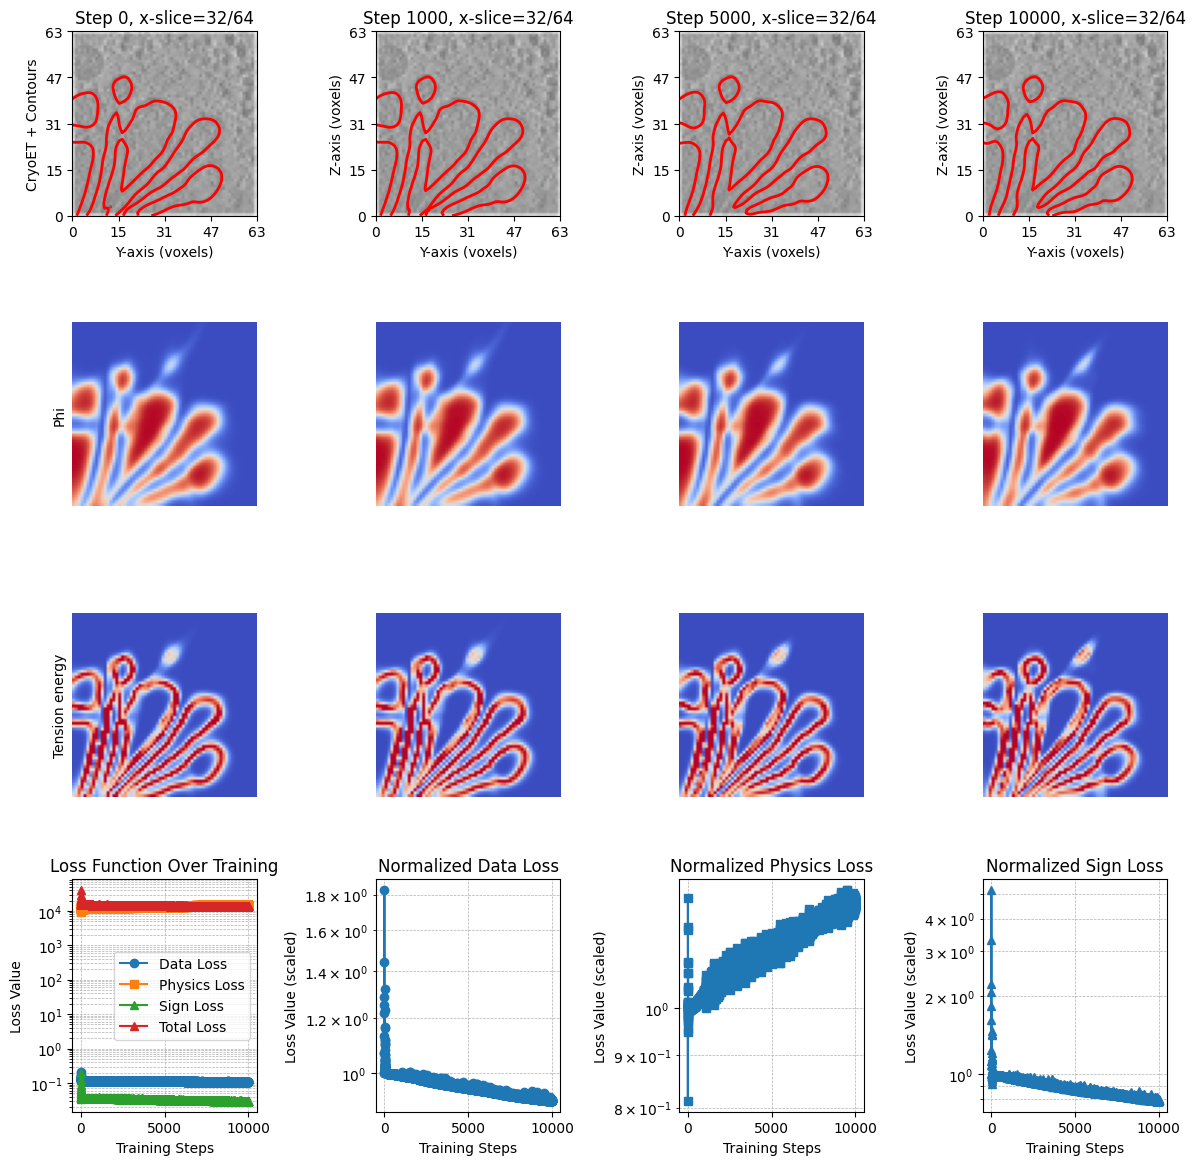

In [2]:
## make one combined image file

import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints
from pinn.cryoet_io import load_mrc_data
from pinn.plot import (
    visualize_cryoET_with_contours,
    visualize_phase,
    # plot_3d_isosurface,
    plot_loss_history_ax,
    plot_normalized_loss_history_ax,
)
from pinn.utils import assemble_loss_history

GRID_SIZE = 64
lambda_1 = 100000
lambda_2 = 0
lambda_3 = 100000
shape = "czii_gl_1"
# slice_index = GRID_SIZE //2
slice_index = 32
axis = "x"

steps_to_visualize = [0, 1000, 5000, 10000]
steps_series = list(range(0, 10001, 100))

## ===== LOAD CHECKPOINT ========
# checkpoint_dir = os.path.abspath(f"../outputs/logs/{shape}/lambda_{lambda_1}_{lambda_2}_{lambda_3}")
checkpoint_dir = os.path.abspath(f"../outputs/logs/{shape}/lambda_{lambda_1}_{lambda_2}_{lambda_3}_cont")

print(checkpoint_dir)
checkpoint_data = {}
for step in steps_series:
    checkpoint_path = os.path.join(checkpoint_dir, f"checkpoint_{step}")
    checkpoint_data[step] = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)

## ===== LOAD CRYOET ========
# mrc_file_path = f"../data/synthetic/{shape}.mrc"
# mrc_file_path = f"../data/synthetic/combine/{shape}_a{str(flip_ratio).replace('.', '')}_m{str(missing_ratio).replace('.', '')}.mrc"
mrc_file_path = f"../data/experimental/downsampled/{shape}.mrc"
# mrc_file_path = f"../data/experimental/masked/{shape}.mrc"
cryoET_data = load_mrc_data(mrc_file_path, grid_size=GRID_SIZE)

## ===== MAKE FIGURE ========
fig = plt.figure(figsize=(3*4, 12))

# Row 1: visualize_cryoET_with_contours
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(4, 4, i + 1)
    visualize_cryoET_with_contours(ax, step, checkpoint_data[step], cryoET_data, grid_size=GRID_SIZE, slice_index=slice_index, axis=axis, thresholding=False)
    if i == 0:
        ax.set_ylabel("CryoET + Contours")

# Row 2: visualize_checkpoint_result
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(4, 4, 4 + i + 1)
    visualize_phase(ax, epsilon=0.05, checkpoint=checkpoint_data[step], component="phi",
                    grid_size=GRID_SIZE, slice_index=slice_index, axis=axis, no_label=True, vmin=-1, vmax=1)
    if i == 0:
        ax.set_ylabel("Phi")

# Row 3: plot_3d_isosurface 
for i, step in enumerate(steps_to_visualize):

    # ax = fig.add_subplot(4, 4, 8 + i + 1, projection='3d')
    # plot_3d_isosurface(ax, step, checkpoint_data[step], grid_size=GRID_SIZE)
    # if i == 0:
    #     ax.set_zlabel("3D Isosurface", rotation=180)

    ax = fig.add_subplot(4, 4, 8 + i + 1)
    visualize_phase(ax, epsilon=0.05, checkpoint=checkpoint_data[step], component="tension",
                    grid_size=GRID_SIZE, slice_index=slice_index, axis=axis, no_label=True, vmin=0.0, vmax=1.0)
    if i == 0:
        ax.set_ylabel("Tension energy")

# Row 4: loss history
assembled_loss = assemble_loss_history(checkpoint_data)
ax = fig.add_subplot(4, 4, 12+1)
plot_loss_history_ax(ax, assembled_loss)
for i in [0,1,2]:
    ax = fig.add_subplot(4, 4, 12+i+2)
    if i == 2:
        j = 3
    else:
        j=i
    plot_normalized_loss_history_ax(ax, j, assembled_loss)

plt.tight_layout()
# plt.savefig("../outputs/figs/analysis.png", dpi=300, bbox_inches="tight")
plt.show()

/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/mend_3/lambda_100000_1_100000_cont/checkpoint_10000


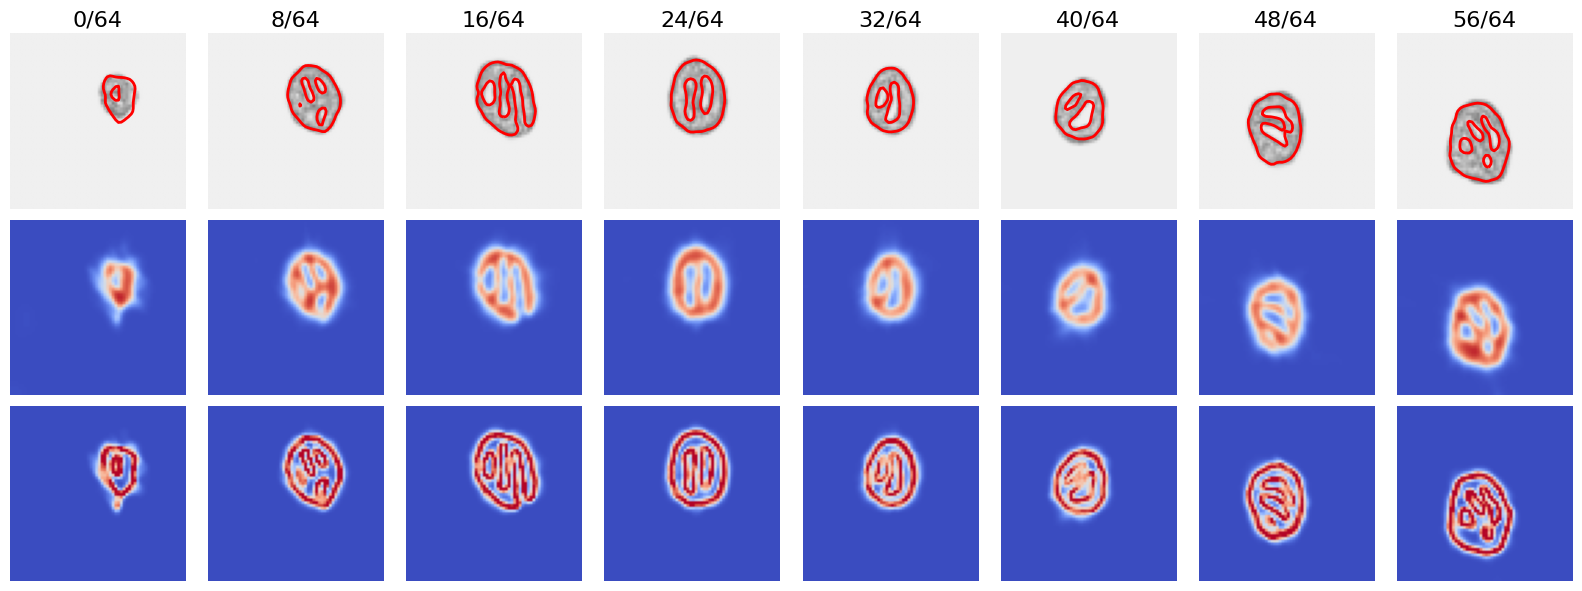

In [13]:
import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints
from pinn.cryoet_io import load_mrc_data
from pinn.plot import visualize_cryoET_with_contours, visualize_physics_loss
from data_generation.mesh_to_cryoet import plot_single_slice
import mrcfile
import jax
import jax.numpy as jnp


GRID_SIZE = 64
shape = "mend_3"
# slice_list = [22, 27, 33, 38, 42]
# slice_list = list(range(17, 48, 5))
slice_list = list(range(0, 64, 8))
# slice_list = [20, 24, 28, 30, 32, 34, 38, 42]
# slice_list = np.arange(0, 64, 10)
# slice_list = np.arange(10, 54, 6)
# slice_list = np.arange(20, 44, 4)
# slice_list = np.arange(28, 35, 1)
# slice_list = np.arange(25, 35, 2)
slice_max = 64
lambda_1 = 100000
lambda_2 = 1
lambda_3 = 100000
step = 10000
epsilon = 0.05
axis = "x"
# axis = "z"

# Load input data
# input_file = f"../data/experimental/downsampled/{shape}.mrc"
# input_file = f"../data/experimental/masked/{shape}.mrc"
input_file = f"../data/experimental/sam3/mrc/{shape}.mrc"
if os.path.exists(input_file):
    volume = load_mrc_data(input_file, grid_size=GRID_SIZE)
    cryo_data = volume

# Load pinn result
# checkpoint_dir = os.path.abspath(f"../outputs/logs/{shape}/lambda_{lambda_1}_{lambda_2}_{lambda_3}")
checkpoint_dir = os.path.abspath(f"../outputs/logs/{shape}/lambda_{lambda_1}_{lambda_2}_{lambda_3}_cont")
checkpoint_path = os.path.join(checkpoint_dir, f"checkpoint_{step}")
print(checkpoint_path)
pinn_data = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)

        
# Plot 
n = len(slice_list)    # slice columns
m = 3                  # rows

fig = plt.figure(figsize=(2*n, 2*m))

for j, slice_id in enumerate(slice_list): # columns
    ax = fig.add_subplot(m, n, 0 * n + j + 1)
    visualize_cryoET_with_contours(ax, step, pinn_data, cryo_data, grid_size=GRID_SIZE, 
                                   slice_index=slice_id, axis=axis, no_label=True, thresholding=False)

    # --- column label ---
    ax.set_title(f"{slice_id}/{slice_max}", fontsize=16)

for j, slice_id in enumerate(slice_list): # columns
    ax = fig.add_subplot(m, n, 1 * n + j + 1)
    visualize_physics_loss(ax, epsilon=epsilon, checkpoint=pinn_data, component="phi",
                           grid_size=GRID_SIZE, slice_index=slice_id, axis=axis, no_label=True, vmin=-1, vmax=1)

for j, slice_id in enumerate(slice_list): # columns
    ax = fig.add_subplot(m, n, 2 * n + j + 1)
    visualize_physics_loss(ax, epsilon=epsilon, checkpoint=pinn_data, component="tension",
                               grid_size=GRID_SIZE, slice_index=slice_id, axis=axis, no_label=True, vmin=0, vmax=400)

    
plt.tight_layout()
# plt.savefig(f"../outputs/figs/sync/experiment/jake_raw.png", dpi=600, bbox_inches="tight")
plt.show()

In [16]:
## Interactive 3d viewer

import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints
from pinn.plot import show_isosurface_plotly

import plotly.io as pio
pio.renderers.default = "iframe"   # or "notebook_connected"

GRID_SIZE = 64
lambda_1 = 100000
lambda_2 = 1
lambda_3 = 100000
shape = "mend_3"
step = 10000

# Load checkpoint data
# checkpoint_dir = os.path.abspath(f"../outputs/logs/{shape}/lambda_{lambda_1}_{lambda_2}_{lambda_3}")
checkpoint_dir = os.path.abspath(f"../outputs/logs/{shape}/lambda_{lambda_1}_{lambda_2}_{lambda_3}_cont")
checkpoint_path = os.path.join(checkpoint_dir, f"checkpoint_{step}")
checkpoint_data = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)

# Plot figures
fig = show_isosurface_plotly(
    checkpoint = checkpoint_data,
    grid_size=GRID_SIZE,
    level=0.0,
    opacity=1.0,
    transpose=True, 
    show_axes=True,
    material="membrane",
    x_range=(-0.5,0.42),
)

fig

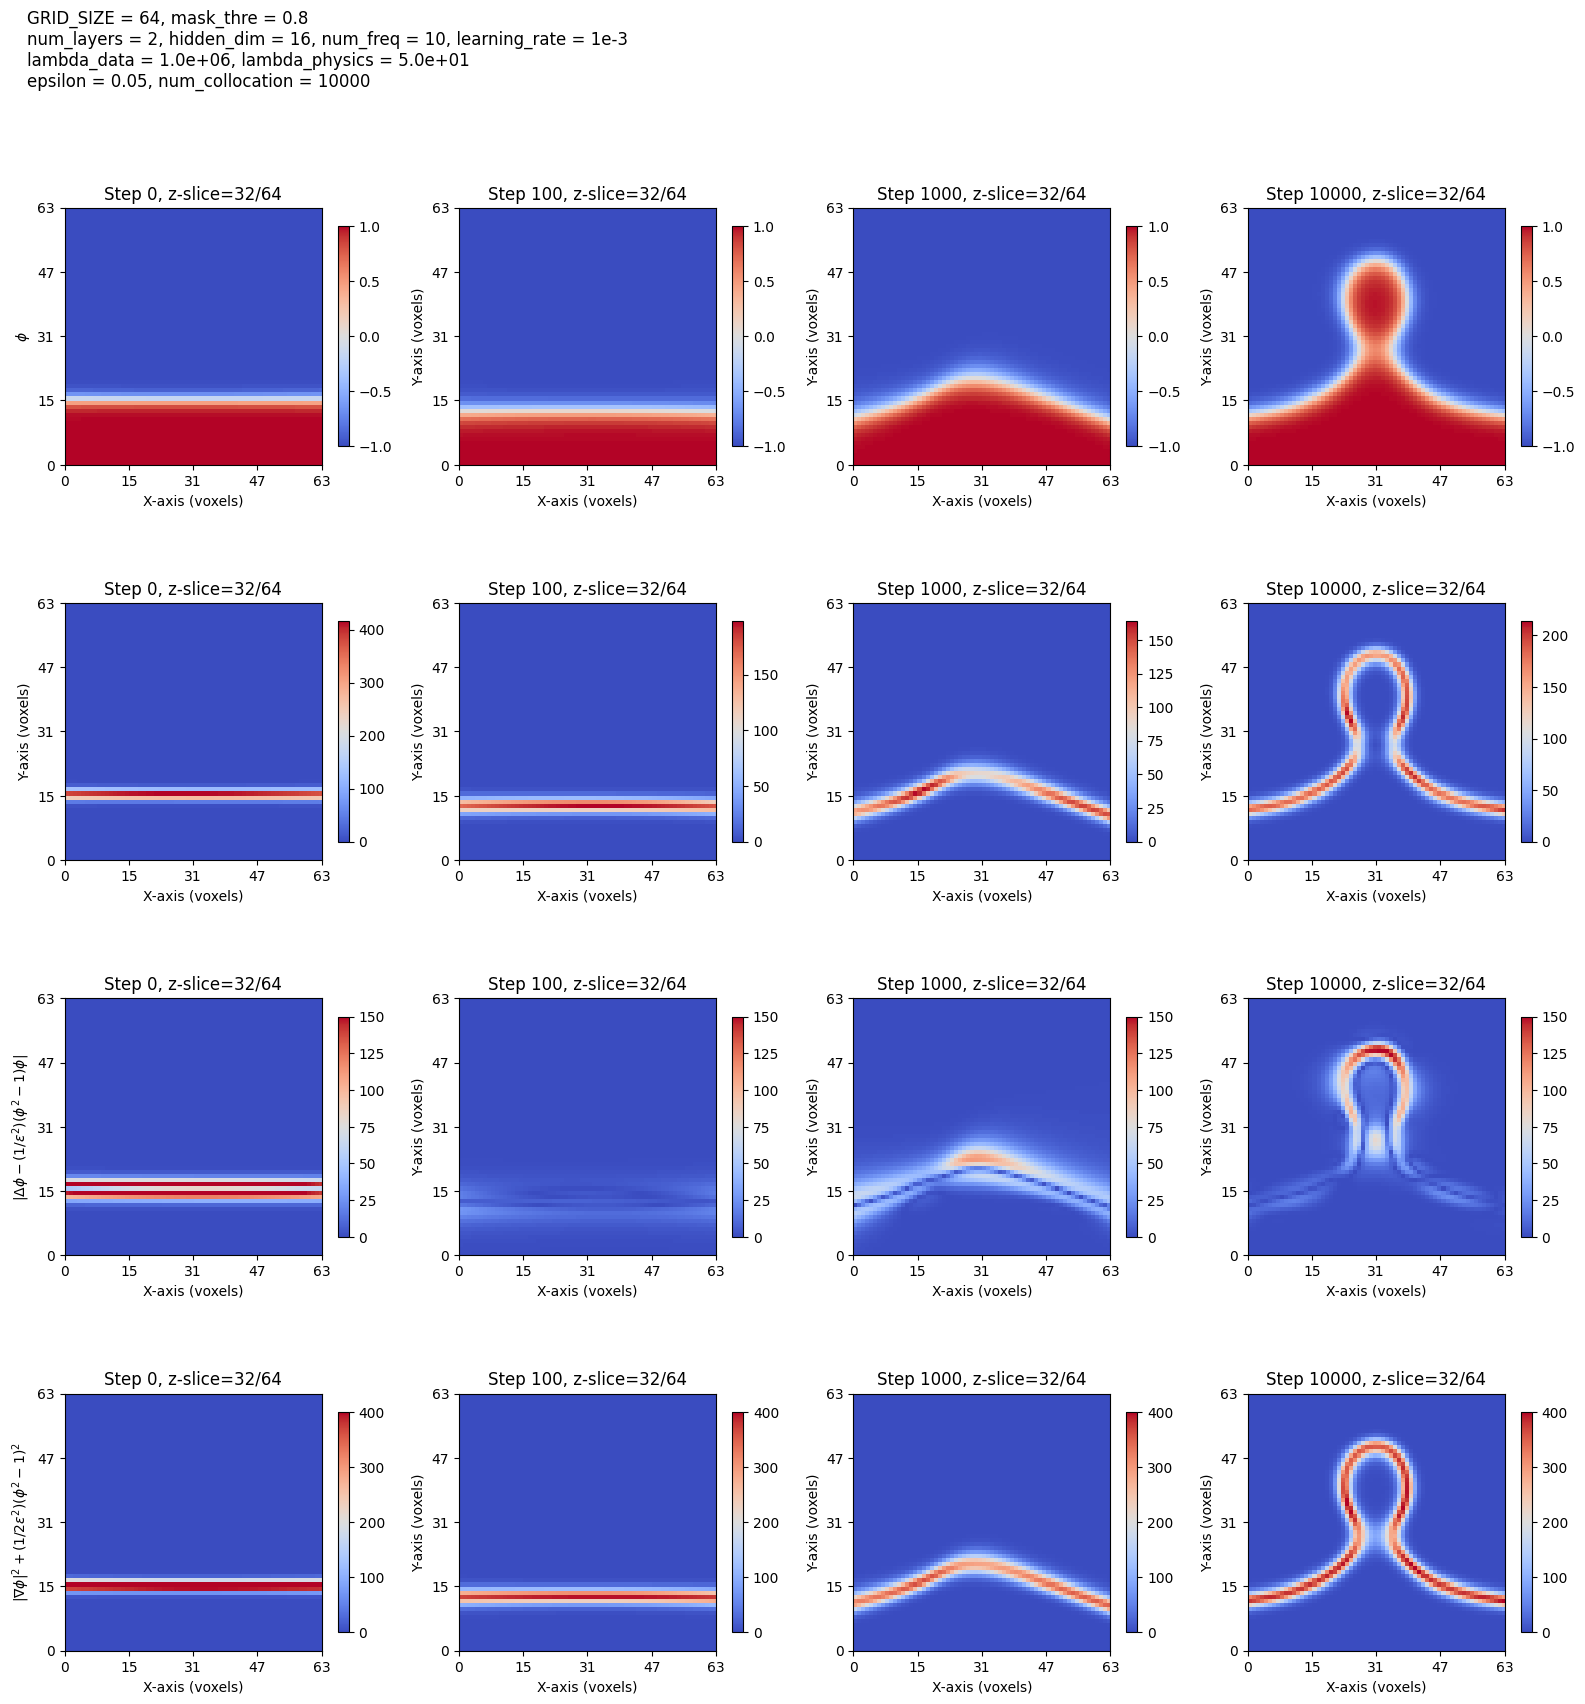

In [11]:
## make one combined physics analysis image

import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints
from pinn.cryoet_io import load_mrc_data
from pinn.model import PINN
from pinn.plot import (
    visualize_checkpoint_result,
    visualize_physics_loss,
)
from pinn.utils import assemble_loss_history

GRID_SIZE = 64
lambda_1 = 1000000
lambda_2 = 50
num_collocation = 10000
num_layers = 2
epsilon = 0.05
shape = "bud_04"

# steps_to_visualize = [0, 200, 600, 1000]
# steps_to_visualize = [0, 2000, 6000, 10000]
# steps_to_visualize = [0, 1000, 6000, 10000]
steps_to_visualize = [0, 100, 1000, 10000]
# steps_to_visualize = [0, 20000, 35000, 50000]
# steps_to_visualize = [0, 30000, 60000, 90000]

# Load checkpoint data
# checkpoint_dir = os.path.abspath(f"../outputs/logs/{shape}/lambda_{lambda_1}_{lambda_2}")
checkpoint_dir = os.path.abspath(f"../outputs/logs/{shape}/data_0926/clean/plane/lambda_{lambda_1}_{lambda_2}")
checkpoint_data = {}
for step in steps_to_visualize:
    checkpoint_path = os.path.join(checkpoint_dir, f"checkpoint_{step}")
    checkpoint_data[step] = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)

# Load CryoET data
mrc_file_path = f"../data/synthetic/{shape}.mrc"
# mrc_file_path = f"../data/synthetic/flip_noise/{shape}_f{str(flip_ratio).replace('.', '')}.mrc"
# mrc_file_path = f"../data/synthetic/flip_noise/{shape}_f{str(flip_ratio).replace('.', '')}_w{wedge_axis}.mrc"
cryoET_data = load_mrc_data(mrc_file_path, grid_size=GRID_SIZE)


# Create a big figure with 4 rows: cryoET + contours, prediction result, 3D isosurface, and leave room for loss plots
fig = plt.figure(figsize=(4*4, 4*4))


# Row 1: Phi
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(4, 4, i + 1)
    visualize_physics_loss(ax, epsilon=epsilon, step=step,
                           checkpoint=checkpoint_data[step], component="phi",
                           grid_size=GRID_SIZE, slice_index=32, axis="z", vmin=-1, vmax=1)
    # visualize_checkpoint_result(ax, step, checkpoint_data[step], grid_size=GRID_SIZE, slice_index=32, axis="z", colorbar = True)
    if i == 0:
        ax.set_ylabel(r"$\phi$")

# Row 2: data loss
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(4, 4, 4 + i + 1)
    # visualize_physics_loss(ax, epsilon=epsilon, step=step,
    #                        checkpoint=checkpoint_data[step], component="laplacian",
    #                        grid_size=GRID_SIZE, slice_index=int(GRID_SIZE/2), axis="z", vmin=0, vmax=5e-7, cryoET_data=cryoET_data)
    visualize_physics_loss(ax, epsilon=epsilon, step=step,
                           checkpoint=checkpoint_data[step], component="grad_norm2",
                           grid_size=GRID_SIZE, slice_index=int(GRID_SIZE/2), axis="z", cryoET_data=cryoET_data)
    # if i == 0:
        # ax.set_ylabel(r"Data loss")

# Row 3: physics loss
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(4, 4, 8 + i + 1)
    visualize_physics_loss(ax, epsilon=epsilon, step=step,
                           checkpoint=checkpoint_data[step], component="residual",
                           grid_size=GRID_SIZE, slice_index=32, axis="z", vmin=0, vmax=150)

    if i == 0:
        ax.set_ylabel(r"$|\Delta \phi - (1/\epsilon^2)(\phi^2 - 1)\phi|$")

# Row 4: tension energy
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(4, 4, 12 + i + 1)
    visualize_physics_loss(ax, epsilon=epsilon, step=step,
                           checkpoint=checkpoint_data[step], component="tension",
                           grid_size=GRID_SIZE, slice_index=int(GRID_SIZE/2), axis="z", vmin=0, vmax=400)
    if i == 0:
        ax.set_ylabel(r"$|\nabla \phi|^2 + (1/2\epsilon^2) (\phi^2 -1)^2$")
        # ax.set_ylabel(r"$|\nabla\phi|^2$")


info_text = (
    f"GRID_SIZE = {GRID_SIZE}, mask_thre = 0.8\n"
    f"num_layers = {num_layers}, hidden_dim = 16, num_freq = 10, learning_rate = 1e-3\n"
    f"lambda_data = {lambda_1:.1e}, lambda_physics = {lambda_2:.1e}\n"
    f"epsilon = {epsilon}, num_collocation = {num_collocation}"
)

fig.text(
    0.02, 1.08,  # (x, y) position in figure coordinates
    info_text,
    fontsize=12,
    ha='left',
    va='top'
)

plt.tight_layout()
# plt.savefig("../outputs/figs/physics.png", dpi=300, bbox_inches="tight")
plt.show()

In [7]:
# Make a movie

import matplotlib.pyplot as plt
import os
from pinn.plot import plot_3d_isosurface
from flax.training import checkpoints
import imageio
import re

lambda_1 = 1000000
lambda_2 = 0
shape = "bud_04"
flip_ratio=0.15
# wedge_axis='z'
version = "0926/plane"
str_flip = str(flip_ratio).replace('.', '')


steps_to_visualize = list(range(0, 3001, 100))
log_dir = os.path.abspath(f"../outputs/logs/{shape}/data_{version}/f{str_flip}/lambda_{lambda_1}_{lambda_2}/")
frame_dir = os.path.join(log_dir, f"3d_iso")

def save_isosurface_frame(step, checkpoint, save_dir="frames", grid_size=64):
    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111, projection='3d')
    plot_3d_isosurface(ax, step, checkpoint, grid_size)
    
    os.makedirs(save_dir, exist_ok=True)
    filename = os.path.join(save_dir, f"frame_{step:06d}.png")
    plt.savefig(filename, dpi=150)
    plt.close(fig)

def make_movie_from_frames(frame_dir="frames", output="movie.mp4", fps=12, start=0, end=30000):
    # Match files like frame_XXXX.png and extract the numeric part
    pattern = re.compile(r"frame_(\d+)\.png")

    frames = []
    for fname in os.listdir(frame_dir):
        match = pattern.match(fname)
        if match:
            index = int(match.group(1))
            if start <= index <= end:
                frames.append((index, os.path.join(frame_dir, fname)))

    frames.sort(key=lambda x: x[0])

    with imageio.get_writer(output, fps=fps) as writer:
        for _, frame_path in frames:
            image = imageio.imread(frame_path)
            writer.append_data(image)

for step in steps_to_visualize:
    ckpt_path = os.path.join(log_dir, f"checkpoint_{step}")
    ckpt_data = checkpoints.restore_checkpoint(ckpt_dir=ckpt_path, target=None)
    print(f"saving step {step}")
    save_isosurface_frame(step, ckpt_data, save_dir=frame_dir)

output=os.path.abspath(f"{frame_dir}/movie.mp4")
make_movie_from_frames(frame_dir=frame_dir, output=output)

saving step 0
saving step 100
saving step 200
saving step 300
saving step 400
saving step 500
saving step 600
saving step 700
saving step 800
saving step 900
saving step 1000
saving step 1100
saving step 1200
saving step 1300
saving step 1400
saving step 1500
saving step 1600
saving step 1700
saving step 1800
saving step 1900
saving step 2000
saving step 2100
saving step 2200
saving step 2300
saving step 2400
saving step 2500
saving step 2600
saving step 2700
saving step 2800
saving step 2900
saving step 3000


/tmp/ipykernel_40035/3169113993.py:49: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(frame_path)


In [9]:
import numpy as np
import matplotlib.pyplot as plt

def manual_sign_labeler(
    volume,                     # 3D numpy array, e.g. your cryoET intensity or a mask
    axis="z",                   # "x", "y", or "z"
    slice_index=None,
    point_mode=+1,              # current label: +1 or -1
    save_path="manual_signs.npz",
    vmin=None,
    vmax=None,
):
    """
    Interactive manual labeler for sign anchors.

    Controls:
      - Mouse click: add point at (x,y) on current slice with current sign.
      - '1': set mode to +1
      - '2': set mode to -1
      - 'j' / 'k': previous / next slice
      - 'x'/'y'/'z': change slicing axis
      - 'u': undo last point
      - 's': save to .npz (points in [-1,1]^3, sign in {-1,+1})
      - 'q': close

    Returns:
      signs dict: {"points": (N,3) float32 in [-1,1], "sign": (N,) float32}
    """
    vol = np.asarray(volume)
    assert vol.ndim == 3, "volume must be 3D"

    # storage in voxel indices first
    picked = []   # list of (ix, iy, iz, sign)

    # view state
    state = {"axis": axis, "slice": slice_index, "mode": int(point_mode)}

    def axis_len(ax):
        return {"x": vol.shape[0], "y": vol.shape[1], "z": vol.shape[2]}[ax]

    if state["slice"] is None:
        state["slice"] = axis_len(state["axis"]) // 2

    fig, ax = plt.subplots(figsize=(6, 6))
    scat_pos = ax.scatter([], [], marker="o", s=20, label="+1", alpha=0.9)
    scat_neg = ax.scatter([], [], marker="x", s=20, label="-1", alpha=0.9)
    ax.legend(loc="upper right", frameon=True)

    def get_slice(axname, idx):
        if axname == "x":
            img = vol[idx, :, :]      # (y,z)
            xlabel, ylabel = "y (pix)", "z (pix)"
        elif axname == "y":
            img = vol[:, idx, :]      # (x,z)
            xlabel, ylabel = "x (pix)", "z (pix)"
        else:
            img = vol[:, :, idx]      # (x,y)
            xlabel, ylabel = "x (pix)", "y (pix)"
        return img, xlabel, ylabel

    def set_title():
        ax.set_title(
            f"axis={state['axis']} slice={state['slice']}  |  mode={'+' if state['mode']>0 else '-'}1  "
            f"|  points={len(picked)}"
        )

    def redraw():
        ax.clear()
        img, xlabel, ylabel = get_slice(state["axis"], state["slice"])
        ax.imshow(img.T, origin="lower", vmin=vmin, vmax=vmax)  # transpose for display
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)

        # points on this slice for this axis
        px_pos, py_pos, px_neg, py_neg = [], [], [], []
        for (ix, iy, iz, sgn) in picked:
            if state["axis"] == "x" and ix == state["slice"]:
                # display coords are (y,z)
                (px_pos if sgn > 0 else px_neg).append(iy)
                (py_pos if sgn > 0 else py_neg).append(iz)
            elif state["axis"] == "y" and iy == state["slice"]:
                # display coords are (x,z)
                (px_pos if sgn > 0 else px_neg).append(ix)
                (py_pos if sgn > 0 else py_neg).append(iz)
            elif state["axis"] == "z" and iz == state["slice"]:
                # display coords are (x,y)
                (px_pos if sgn > 0 else px_neg).append(ix)
                (py_pos if sgn > 0 else py_neg).append(iy)

        if len(px_pos):
            ax.scatter(px_pos, py_pos, marker="o", s=25, alpha=0.9, label="+1")
        if len(px_neg):
            ax.scatter(px_neg, py_neg, marker="x", s=25, alpha=0.9, label="-1")

        ax.legend(loc="upper right", frameon=True)
        set_title()
        fig.canvas.draw_idle()

    def on_click(event):
        if event.inaxes != ax:
            return
        # event.xdata, ydata are in displayed pixel coords
        xd = int(round(event.xdata))
        yd = int(round(event.ydata))

        # map displayed coords back to voxel indices (note we plotted img.T)
        # So displayed x corresponds to first index of img, displayed y corresponds to second.
        # For axis:
        # x-slice shows (y,z): displayed (x,y) -> (y,z)
        # y-slice shows (x,z): displayed (x,y) -> (x,z)
        # z-slice shows (x,y): displayed (x,y) -> (x,y)
        if state["axis"] == "x":
            ix = state["slice"]
            iy = xd
            iz = yd
        elif state["axis"] == "y":
            ix = xd
            iy = state["slice"]
            iz = yd
        else:
            ix = xd
            iy = yd
            iz = state["slice"]

        # bounds check
        if not (0 <= ix < vol.shape[0] and 0 <= iy < vol.shape[1] and 0 <= iz < vol.shape[2]):
            return

        picked.append((ix, iy, iz, state["mode"]))
        redraw()

    def on_key(event):
        if event.key == "1":
            state["mode"] = +1
            redraw()
        elif event.key == "2":
            state["mode"] = -1
            redraw()
        elif event.key == "j":
            state["slice"] = max(0, state["slice"] - 1)
            redraw()
        elif event.key == "k":
            state["slice"] = min(axis_len(state["axis"]) - 1, state["slice"] + 1)
            redraw()
        elif event.key in ("x", "y", "z"):
            state["axis"] = event.key
            state["slice"] = axis_len(state["axis"]) // 2
            redraw()
        elif event.key == "u":
            if picked:
                picked.pop()
                redraw()
        elif event.key == "s":
            signs = picked_to_signs(picked, vol.shape)
            np.savez(save_path, points=signs["points"], sign=signs["sign"])
            print(f"Saved {len(signs['sign'])} points to {save_path}")
        elif event.key == "q":
            plt.close(fig)

    def picked_to_signs(picked_list, shape):
        # convert voxel indices -> normalized [-1,1]^3 coordinates
        # shape is (Nx,Ny,Nz)
        Nx, Ny, Nz = shape
        pts = []
        sgn = []
        for (ix, iy, iz, ss) in picked_list:
            x = 2.0 * ix / (Nx - 1) - 1.0
            y = 2.0 * iy / (Ny - 1) - 1.0
            z = 2.0 * iz / (Nz - 1) - 1.0
            pts.append([x, y, z])
            sgn.append(ss)
        return {
            "points": np.asarray(pts, dtype=np.float32),
            "sign": np.asarray(sgn, dtype=np.float32),
        }

    fig.canvas.mpl_connect("button_press_event", on_click)
    fig.canvas.mpl_connect("key_press_event", on_key)

    redraw()
    plt.show()

    # return final signs
    signs = picked_to_signs(picked, vol.shape)
    return signs


In [2]:
%matplotlib widget

/tmp/ipykernel_89390/895929246.py:95: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper right", frameon=True)


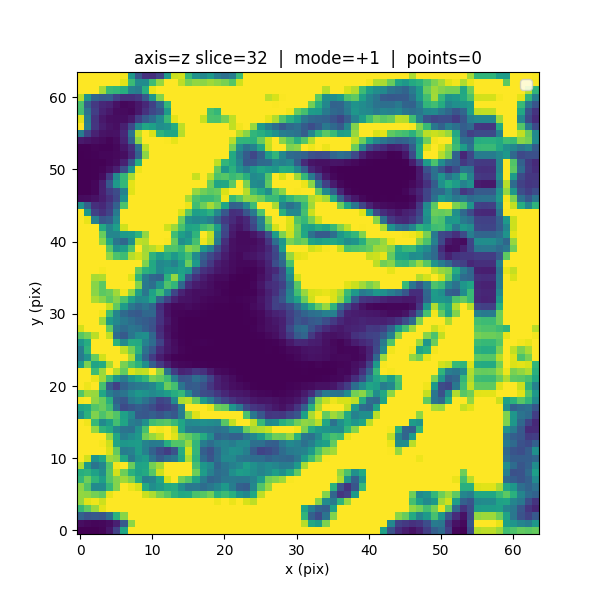

(0,) (0,)
pos: 0 neg: 0


In [10]:
# volume can be your raw cryoET intensity, or a filtered/thresholded version for easier clicking

GRID_SIZE = 64
shape = "mito_1"
mrc_file_path = f"../data/experimental/downsampled/{shape}.mrc"
cryoET_data = load_mrc_data(mrc_file_path, grid_size=GRID_SIZE)
signs = manual_sign_labeler(volume=cryoET_data, axis="z", save_path="manual_signs.npz")

print(signs["points"].shape, signs["sign"].shape)
print("pos:", np.sum(signs["sign"] == 1), "neg:", np.sum(signs["sign"] == -1))

In [5]:
import napari
import numpy as np

def napari_sign_labeler(volume):
    """
    volume: 3D numpy array (Z,Y,X) or (X,Y,Z)
    """
    viewer = napari.Viewer(ndisplay=2)
    viewer.add_image(volume, name="cryoET", contrast_limits=[np.percentile(volume, 5),
                                                             np.percentile(volume, 99)])

    # Two point layers: outside (+1), inside (-1)
    pts_pos = viewer.add_points(
        name="sign_+1",
        ndim=3,
        size=4,
        face_color="red",
    )
    pts_neg = viewer.add_points(
        name="sign_-1",
        ndim=3,
        size=4,
        face_color="blue",
    )

    print(
        "Napari sign labeling:\n"
        "- Click points in 'sign_+1' layer → outside (+1)\n"
        "- Click points in 'sign_-1' layer → inside (-1)\n"
        "- Scroll to change slices\n"
        "- Close window when done"
    )

    return viewer, pts_pos, pts_neg



In [ ]:
GRID_SIZE = 64
shape = "mito_1"
mrc_file_path = f"../data/experimental/downsampled/{shape}.mrc"
cryoET_data = load_mrc_data(mrc_file_path, grid_size=GRID_SIZE)
viewer, pts_pos, pts_neg = napari_sign_labeler(cryoET_data)


Available platform plugins are: eglfs, linuxfb, minimal, minimalegl, offscreen, vnc, wayland-egl, wayland, wayland-xcomposite-egl, wayland-xcomposite-glx, webgl, xcb.


Available platform plugins are: eglfs, linuxfb, minimal, minimalegl, offscreen, vnc, wayland-egl, wayland, wayland-xcomposite-egl, wayland-xcomposite-glx, webgl, xcb.



In [6]:
# %echo $DISPLAY
# %echo $XDG_SESSION_TYPE
python -c "import os; print('DISPLAY=', os.environ.get('DISPLAY'))"

UsageError: Line magic function `%%` not found.
